# 7. Wizualizacja danych w Pandas

**Pandas ma wbudowane metody do tworzenia wykresów** - używają matplotlib pod spodem, ale są dużo wygodniejsze do szybkiej eksploracji.

**Kiedy używać:**
- ✅ Szybka eksploracja danych → `df.plot()`
- ✅ Prosty wykres z jednej linii kodu
- ❌ Pełna kontrola nad każdym elementem → używaj matplotlib bezpośrednio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Wczytanie danych (z wcześniejszych notebooków)

In [2]:
# Dane pogodowe
df_pogoda = pd.read_csv('../../data/pogoda.csv', parse_dates=['data'])

# Dane sprzedażowe
df_sprzedaz = pd.read_csv('../../data/sprzedaz.csv', parse_dates=['data'])
df_sprzedaz['wartosc'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

# Dane pracowników
df_prac = pd.read_csv('../../data/pracownicy.csv')

print("✅ Dane wczytane")

✅ Dane wczytane


In [4]:
df_pogoda

,data,temperatura,opady,wilgotnosc
0,2023-01-01,-2.5,0.0,75
1,2023-01-02,-3.8,0.5,78
2,2023-01-03,-1.2,0.0,72
3,2023-01-04,0.5,1.2,80
4,2023-01-05,1.2,2.5,82
...,...,...,...,...
165,2024-05-06,21.2,0.0,50
166,2024-05-07,20.5,1.5,54
167,2024-05-08,18.8,6.5,65
168,2024-05-09,17.5,3.5,62


## 1. Wykres liniowy - `df.plot()` lub `df.plot.line()`

<Axes: xlabel='data'>

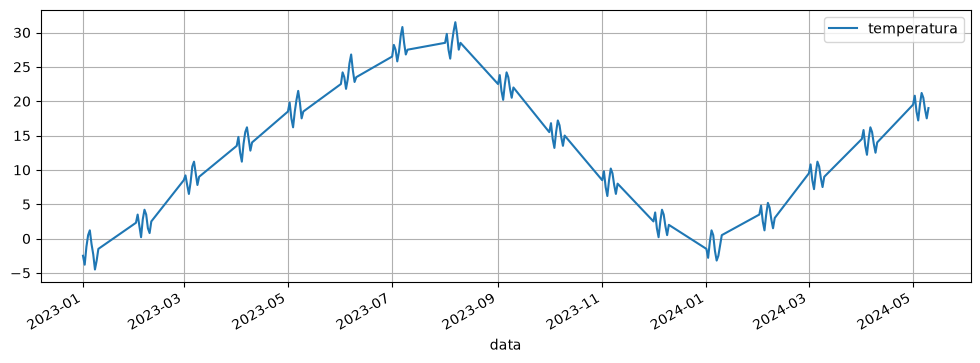

In [8]:
# Jedna linia kodu!
df_pogoda.plot(x='data', y='temperatura', grid=True, figsize=(12, 4))

<Axes: title={'center': 'Temperatura i wilgotność'}, xlabel='data'>

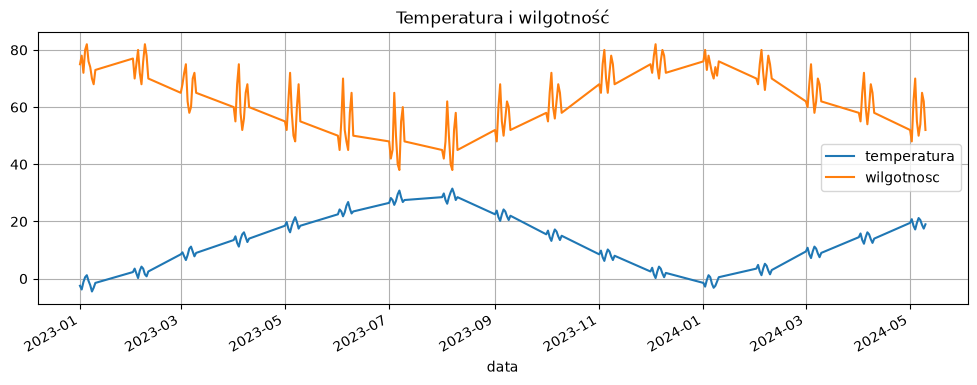

In [9]:
# Wiele linii naraz
df_pogoda.plot(x='data', y=['temperatura', 'wilgotnosc'], grid=True, figsize=(12, 4), title="Temperatura i wilgotność")

## 2. Wykres słupkowy - `df.plot.bar()` i `df.plot.barh()`

<Axes: xlabel='kategoria'>

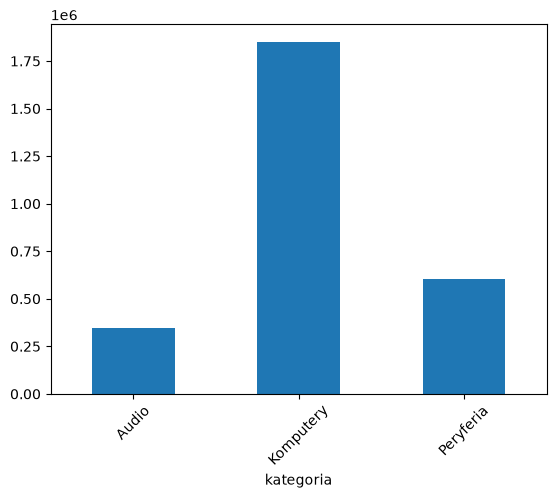

In [12]:
# Sprzedaż według kategorii
sprzedaz_kat = df_sprzedaz.groupby('kategoria')['wartosc'].sum()

sprzedaz_kat.plot.bar(rot=45)

<Axes: ylabel='kategoria'>

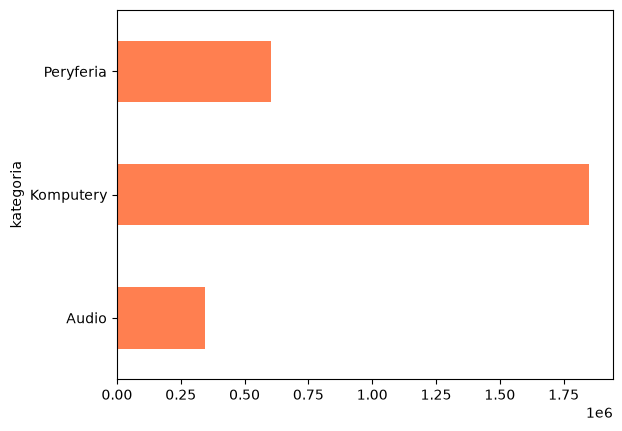

In [14]:
# Wykres poziomy (barh) - lepszy dla długich nazw
top_produkty = df_sprzedaz.groupby('produkt')['wartosc'].sum().nlargest(8)

sprzedaz_kat.plot.barh(color='coral')

## 3. Histogram - `df.plot.hist()`

<Axes: ylabel='Frequency'>

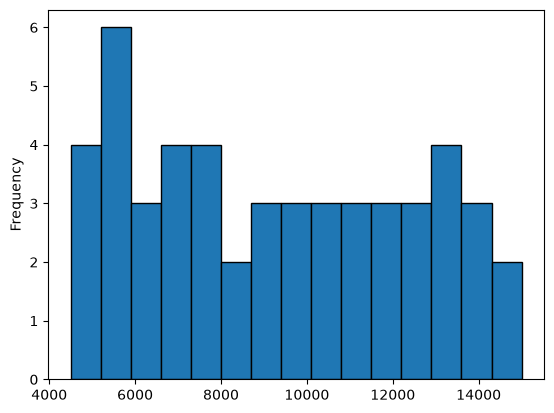

In [18]:
# Rozkład pensji
df_prac['pensja'].plot.hist(bins=15, edgecolor='black')

<Axes: ylabel='Frequency'>

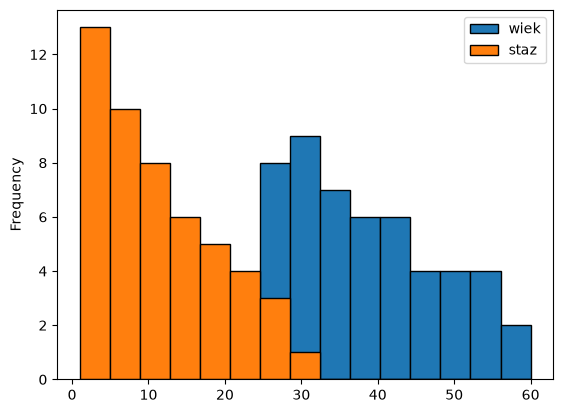

In [19]:
# Wiele histogramów naraz
df_prac[ ['wiek', 'staz'] ].plot.hist(bins=15, edgecolor='black')

## 4. Wykres punktowy - `df.plot.scatter()`

<Axes: xlabel='wiek', ylabel='pensja'>

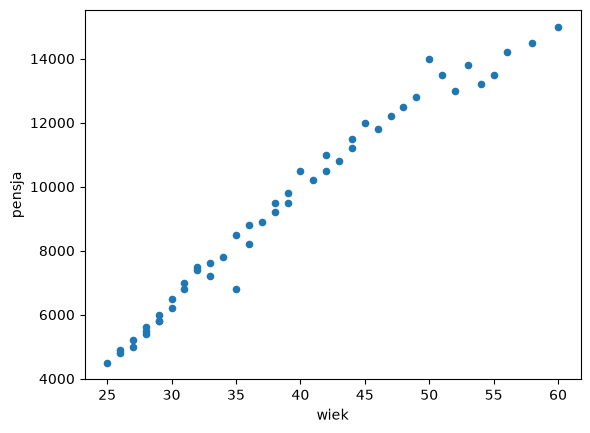

In [23]:
# Korelacja wiek vs pensja
df_prac.plot.scatter(x='wiek', y='pensja')

<Axes: xlabel='wiek', ylabel='pensja'>

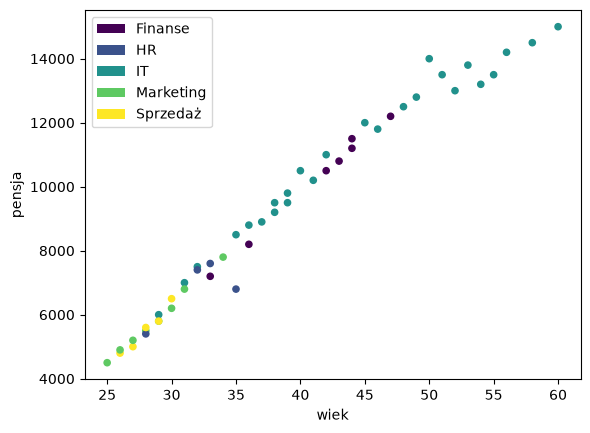

In [24]:
# Z kolorem według kategorii (działu)
df_prac.plot.scatter(x='wiek', y='pensja', c='dzial')

## 5. Wykres kołowy - `df.plot.pie()`

<Axes: >

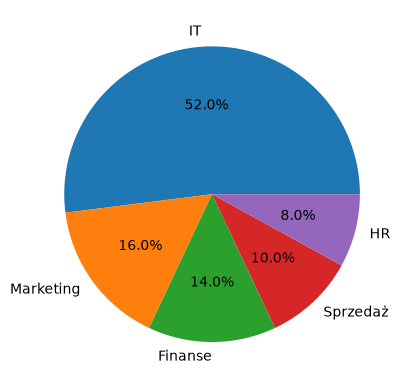

In [31]:
# Liczba pracowników według działów
df_prac['dzial'].value_counts().plot.pie(autopct='%1.1f%%')

## 6. Box plot - `df.plot.box()`

Przydatny do wykrywania wartości odstających (outliers).

Text(0, 0.5, 'Pensja [zł]')

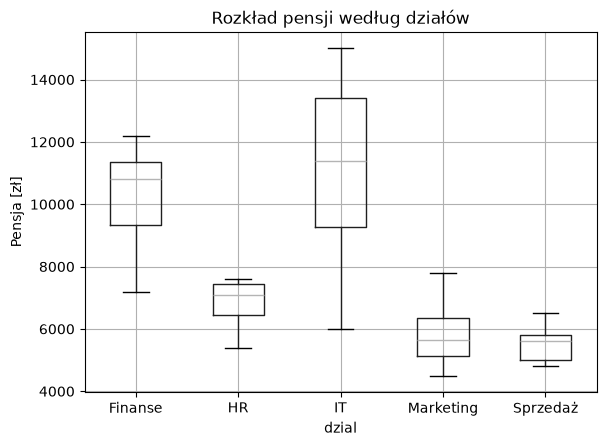

In [32]:
# Pensja według działów
df_prac.boxplot(column='pensja', by='dzial')
plt.suptitle('')  # Usuń domyślny tytuł
plt.title('Rozkład pensji według działów')
plt.ylabel('Pensja [zł]')

## 7. Wykres obszarowy - `df.plot.area()`

<Axes: xlabel='data'>

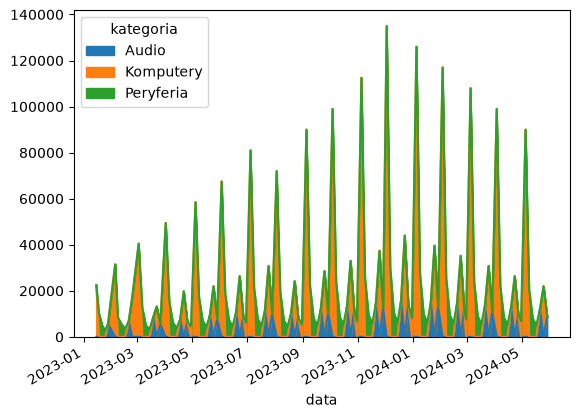

In [34]:
# Sprzedaż w czasie według kategorii (stacked area)
sprzedaz_czas = df_sprzedaz.groupby(['data', 'kategoria'])['wartosc'].sum().unstack()

sprzedaz_czas.plot.area()

## 8. Dostęp do obiektów matplotlib (gdy potrzebujesz więcej kontroli)

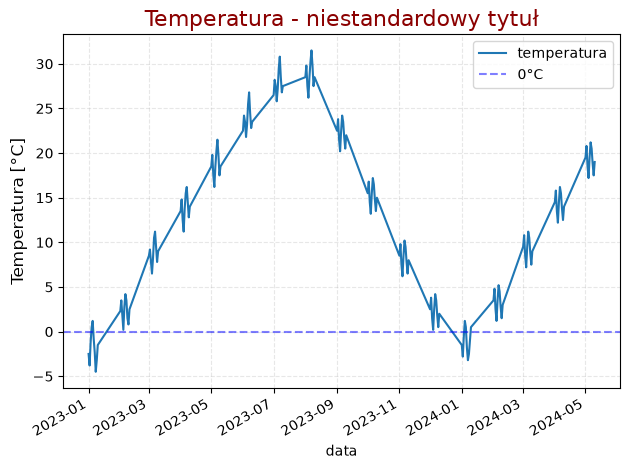

In [35]:
# pandas.plot() zwraca obiekt Axes!
ax = df_pogoda.plot(x='data', y='temperatura')

# Możesz teraz modyfikować jak w czystym matplotlib
ax.set_title('Temperatura - niestandardowy tytuł', fontsize=16, color='darkred')
ax.set_ylabel('Temperatura [°C]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.axhline(y=0, color='blue', linestyle='--', alpha=0.5, label='0°C')
ax.legend()

plt.tight_layout()

## 9. Subplots - `df.plot(subplots=True)`

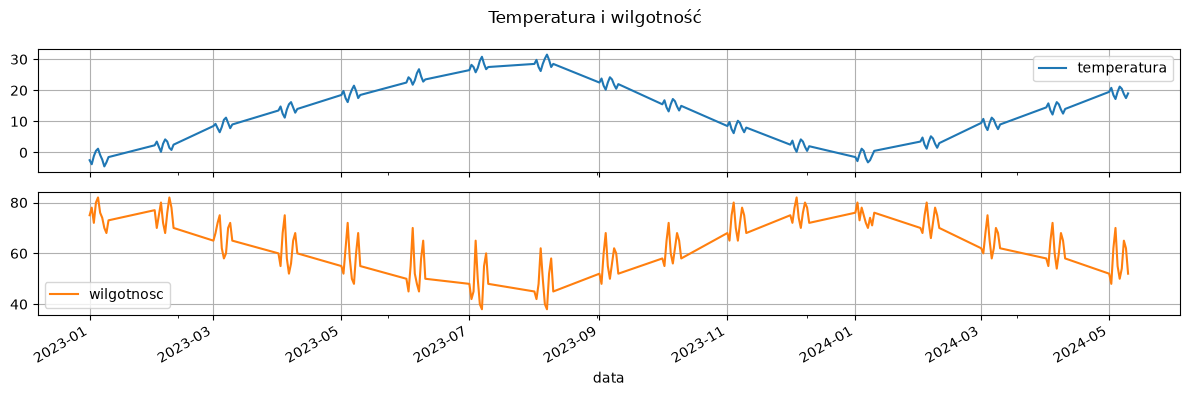

In [36]:
# Wiele wykresów obok siebie
df_pogoda.plot(x='data', y=['temperatura', 'wilgotnosc'], grid=True, subplots=True, figsize=(12, 4), title="Temperatura i wilgotność")

plt.tight_layout()

## Podsumowanie - Pandas vs Matplotlib

| Aspekt | `df.plot()` (Pandas) | `matplotlib` bezpośrednio |
|--------|---------------------|---------------------------|
| **Szybkość pisania** | ✅ Bardzo szybkie (1 linia) | ❌ Więcej kodu |
| **Eksploracja danych** | ✅ Idealne | ⚠️ Nadmiarowe |
| **Pełna kontrola** | ⚠️ Ograniczona | ✅ Pełna |
| **Złożone układy** | ❌ Trudne | ✅ Łatwe |
| **Dostosowanie** | ⚠️ Podstawowe | ✅ Każdy detal |
| **Integracja z DataFrame** | ✅ Natywna | ❌ Ręczne przekazywanie danych |

**Rekomendacja:**
- 🔍 **Eksploracja danych** → `df.plot()`
- 📊 **Prezentacje/publikacje** → matplotlib bezpośrednio
- 🎛️ **Dashboardy** → matplotlib lub plotly

**Najlepsze podejście:** Zacznij od `df.plot()`, a jak potrzebujesz więcej kontroli - przejdź na matplotlib:

```python
# Krok 1: Szybka eksploracja
df.plot(x='date', y='value')  # Zobacz czy warto dalej analizować

# Krok 2: Jeśli trzeba więcej kontroli
ax = df.plot(x='date', y='value')  # Użyj pandas, ale...
ax.set_title('Custom')  # ...modyfikuj przez matplotlib

# Krok 3: Pełna kontrola (publikacja)
fig, ax = plt.subplots()
ax.plot(df['date'], df['value'])  # Ręcznie wszystko
```